# Proof of Concept for Spatial Cross-Regressive Model

Following issues with implementing all spatial econometric models, the purpose of this notebook is to showcase proof of efficacy for a Spatial Cross-Regressive Model (SLX). Issues arose in implementing the other models from this family (SAC, SAR, SEM, SDM, SDEM, GNM) because python libraries as of yet are more geared towards inference rather than prediction, thus being unsuitable for nowcasting. Also, on further examination, these models were deemed less appropriate.

To recreate this notebook, you will need the output parquet file from the data engineering pipeline, the geography lookup csv and the 2025 index of multiple deprivation scores csv file. 

Also note, in some literature an SLX is refered to as an SLM.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression, Ridge

import json

from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
import geopandas as gpd
from shapely.geometry import shape


RANDOM_STATE = 19


## Background on Spatial Econometric Models


These are regression models which incorporate spatial dependence using spatial weights and adjacency matrices. 

At the core of all of these is an adjacency matrix $W$ where in the context of our project:

- $Wij = 1$ if LSOA $i$ and $j$ are neighbours  

- $0$ otherwise

Note that these are often standardised such that rows sum to 1. For example, an LSOA with 5 neighbours will then have $Wij = 0.2$

Being regression models, they usually take the form: 

$$y_i=β_0+x_(i,1) β_1+x_(i,2) β_2+⋯+x_(i,k) β_k+ϵ_i$$

Where:
- $𝑖$ is an individual LSOAs, so that $1 ≤ 𝑖 ≤ 268$ (since there are 268 LSOAs in Bristol)
- $y_i$ is the deprivation score for LSOA $𝑖$
- $β_0$ is a constant parameter term (this isn’t necessarily nonzero)
- $k$ is the number of features used in the model
- $x_(i,1)… x_(i,k)$ are the values of features for LSOA $𝑖$
- $β_(i,0)… β_(i,k)$ are the coefficients which the model will estimate for LSOA $𝑖$
- $ϵ_i$ is the error term for LSOA $𝑖$

Or more broadly:

$$Y=Xβ+ ϵ$$

Some definitions paraphrased from the source in the context of our project:
- Endogenous Interaction effects – If the deprivation score of an LSOA is influenced by the deprivation score of a neighbouring LSOA. 
- Exogenous Interaction effects – If the deprivation score of an LSOA is influenced by the feature space of a neighbouring LSOA.
- Interaction between error terms – If the error term of an LSOA is affected by the error term of a neighbouring LSOA.

Spatial Econometric models aim to capture one or more of these effects. An SLX model captures exogenous interaction effects.

Which, is of the form:

$$Y=Xβ+WXθ+ϵ$$

Where:
- $W$ is the adjacency matrix.
- $θ$ holds spatial weights, the coefficients for feature spillover. Meaning, how much neighbouring features affect local deprivation.

Other models in this family have been mentioned for lacking libraries that support prediction in python. R does have maintained libraries for this, however on further thought, these models may be inappropriate for our use case. Since deprivation score is not an observable feature but instead calculated by the ONS using linear combinations of measured indicators, deprivation scores themselves do not influence each other in a predictive way. They do still likely observe spatial grouping, but this is because the features used in calculating teh score may group spatially. Therefore, in our case modelling for an endogenous interaction effect would be dubious. Also, interaction between error terms is more interesting for inference rather than prediction.

The explanation for why endogenous interactions should not be considered here do however highlight how exogenous interaction effects are relevant to our project! It is indeed likely that areas with more universal claimants have neighbouring areas where the same is true, especially on an LSOA scale.

Thus, SLX is chosen over the other models in the family (SAR, SEM, SAC, SDM, etc...). Also, because the capturing the other effects involves having input from neighbouring areas output scores/error terms, the other models cannot be estimated using OLS. Estimation by OLS is only possible for SLX models.


<small>Background is summarised and adpated from:
(Please refer to the literature review)

- Gulati, R. (n.d.) Spatial econometric models (rev.). Asian Development Bank. Available at: https://www.adb.org/sites/default/files/event/978811/files/sessionz20-drrachita-gulati-spatial-econometric-models-rev.pdf [Accessed: 8 March 2026]
- Rüttenauer, T. (2025) Spatial Data Analysis. UCL Social Research Institute, University College London. Available at: https://arxiv.org/pdf/2402.09895 [Accessed: 8 March 2026].


</small>

## Preparation For Modelling

### Get Core Dataset

#### Perform Loads and Joins

In [2]:
# Load dataset and imd to create merged dataset with target variable

combined_indicators = pd.read_parquet('combined_indicators.parquet', engine='fastparquet')

imd_scores = pd.read_csv('imd_2025_scores.csv')

imd_scores.rename(columns={'LSOA code (2021)': 'lsoa_code',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

# get combiend dataset
df = combined_indicators.merge(imd_scores[['lsoa_code', 'imd_score']], on='lsoa_code', how='left')

#### Handle Nulls/Duplicates

Ideally the input dataset doesn't have any null values. However, in the event that it does, these should be dealt with before modelling. 

In [3]:
missingness = df.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(df)) * 100
missingness_df = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

df = df.drop(columns=missingness_df[missingness_df['missing_percent'] > 20]['feature'])
df = df.fillna(df.median(numeric_only=True)) 

### Geospatial Data

In [4]:
lsoa_shapes = pd.read_csv("geography_lookup.csv")

# convert geojson string to geometry
lsoa_shapes["geometry"] = lsoa_shapes["geo_shape"].apply(lambda x: shape(json.loads(x)))
lsoa_shapes = lsoa_shapes[["lsoa_code", "geometry"]]

print(lsoa_shapes.head())

# merge modelling data to get full geo-spatial dataset
gdf = gpd.GeoDataFrame(lsoa_shapes, geometry="geometry", crs="EPSG:4326").merge(df, on="lsoa_code", how="left")


   lsoa_code                                           geometry
0  E01014488  MULTIPOLYGON (((-2.581270401359658 51.47053350...
1  E01014693  MULTIPOLYGON (((-2.581328182358106 51.51617262...
2  E01033909  MULTIPOLYGON (((-2.598659490202402 51.45494441...
3  E01033903  MULTIPOLYGON (((-2.584357699648935 51.45285959...
4  E01032514  MULTIPOLYGON (((-2.59432877773493 51.409612444...


### Define Target, Features and Weight Matrix for Modelling

In [5]:
y = gdf['imd_score'].values
X = gdf.drop(columns=['imd_score', 'geometry','lsoa_code']).values

# Get centroid coordinates for distance matrix
coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

# Compute distance matrix
distances = pairwise_distances(coords)

# Create adjacency: neighbors if within some distance threshold
threshold = 0.01  # roughly 700 meters with 1 ~ 111km
w = (distances < threshold).astype(float)

# row-standardize weights
w = w / w.sum(axis=1, keepdims=True)

C:\Users\danie\AppData\Local\Temp\ipykernel_16284\3663225141.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))


### Observe Target Distribution

Before modelling, the distribution of the target feature is checked. In the event of a strong skew, model performance is expected to suffer.

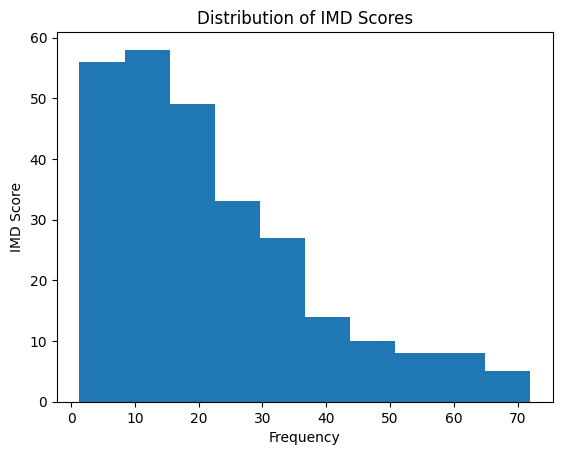

In [6]:
plt.figure()
plt.hist(y, bins=10)
plt.ylabel("IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of IMD Scores")
plt.show()

Due to observed positive skew, a log transformation is used on the target.

In [7]:
y = np.log1p(y)  

Following this, distribution is checked again. Now the target feature is roughly normally distributed.

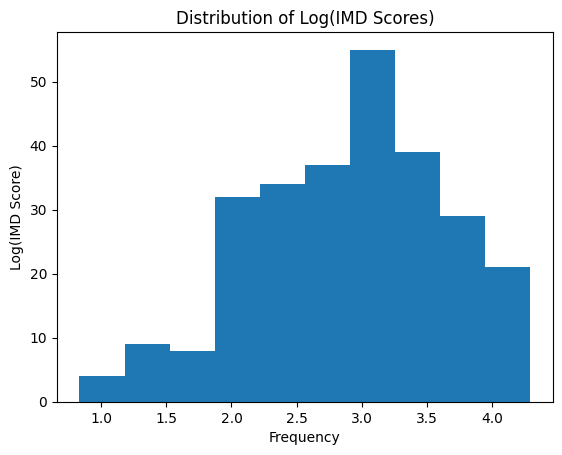

In [8]:
plt.figure()
plt.hist(y, bins=10)
plt.ylabel("Log(IMD Score)")
plt.xlabel("Frequency")
plt.title("Distribution of Log(IMD Scores)")
plt.show()

Descriptive statistics are checked for the target feature to give meaning to RMSE scores when evaluating models.

In [9]:
print("Target Feature Distributions")

print(
    " max:",y.max(),"\n",
    "min:",y.min(),"\n",
    "std:",y.std(),"\n",
    "mean:",y.mean(),"\n",
)

Target Feature Distributions
 max: 4.290445742424427 
 min: 0.8350806764486118 
 std: 0.7394696147261678 
 mean: 2.898798043747689 



### On Feature Reduction

Since the dataset is of the shape p >> n, the feature space must be reduced before modelling. Since it is known that a lot of the features are highly correlated, PCA will be used. More in depth feature selection experiments are performed in the feature engineering repository and so for the purposes of this notebook, PCA will be taken with 20 components. This number is chosen since with 268 records, 20 components double to 40 features due to the spatial lag and so this gives a dataset shape which should work well for a regression model.

## Modelling

### Simple Train/Test Split

An initial simple train/test split is observed before trying cross validation.

In [10]:

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, gdf.index, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
pca = PCA(n_components=20)

X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

WX_train = w[np.ix_(train_idx, train_idx)] @ X_train_pca
WX_test  = w[np.ix_(test_idx, train_idx)]  @ X_train_pca

X_train_slx = np.hstack([X_train_pca, WX_train])
X_test_slx = np.hstack([X_test_pca, WX_test])

    # model
model = LinearRegression().fit(X_train_slx, y_train)
y_pred = model.predict(X_test_slx)

rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 0.11910767123155815
R²: 0.8004144481290297


A relatively high initial R² value is promising, though not conclusive due to simple split. Similarly for an RMSE value which is about a quarter of observed standard deviation on the target.

### Spatial Cross Validated Training

Here centroids are calculated for use in kmeans clustering in order to group LSOAs into 10 geographic clusters. Cross validation is performed across these clusters in order to avoid spatial leakage. This is done using 5 folds, giving 8 clusters for training and 2 for testing in each fold.

In [11]:
# Setup for spatial cross validation 

centroids = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE).fit(centroids)
gdf["cluster_id"] = kmeans.labels_

groups = gdf["cluster_id"].values



gkf = GroupKFold(n_splits=5)

C:\Users\danie\AppData\Local\Temp\ipykernel_16284\4118100698.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))
c:\Users\danie\.venvs\ds\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [39]:
# Perform spatial cross validation using adjacency weights

scores = {
    'RMSE' : [],
    'R²' : [],
    'Beta' : [],
    'Theta' : [],
    }

for train_idx, test_idx in gkf.split(X, y, groups=groups):
    # split
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    

    WX_train = w[np.ix_(train_idx, train_idx)] @ X_train_raw
    WX_test  = w[np.ix_(test_idx, train_idx)]  @ X_train_raw
    
    # combine
    X_train_slx = np.hstack([X_train_raw, WX_train])
    X_test_slx = np.hstack([X_test_raw, WX_test])

    # scale
    scaler = StandardScaler().fit(X_train_slx)
    X_train_scaled = scaler.transform(X_train_slx)
    X_test_scaled = scaler.transform(X_test_slx)
    
    # PCA fitted on train only
    pca = PCA(n_components=100).fit(X_train_scaled)
    X_train = pca.transform(X_train_scaled)
    X_test = pca.transform(X_test_scaled)

    k = X_train.shape[1]
    
    # model
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    

    beta = model.coef_[:k]      # direct effects
    theta = model.coef_[k:]     # spatial lag effects
    
    # Evaluation Metrics
    scores['RMSE'].append(mean_squared_error(y_test, y_pred))
    scores['R²'].append(r2_score(y_test, y_pred))
    scores['Beta'].append(beta)
    scores['Theta'].append(theta)


In [40]:
print("RMSE:")
print("Mean", round(np.mean(scores['RMSE']), 3))
print("Standard Dev.", round(np.std(scores['RMSE']),3), end='\n\n')

print("R Squared:")
print("Mean", round(np.mean(scores['R²']), 3)) 
print("Standard Dev.", round(np.std(scores['R²']),3), end='\n\n')

print("Beta Coefficients:")
print("Mean", round(np.mean(scores['Beta']), 3))
print("Standard Dev.", round(np.std(scores['Beta']),3), end='\n\n')

print("Theta Coefficients:")
print("Mean", round(np.mean(scores['Theta']), 3))
print("Standard Dev.", round(np.std(scores['Theta']),3))

RMSE:
Mean 0.142
Standard Dev. 0.055

R Squared:
Mean 0.632
Standard Dev. 0.216

Beta Coefficients:
Mean -0.002
Standard Dev. 0.028

Theta Coefficients:
Mean nan
Standard Dev. nan


c:\Users\danie\.venvs\ds\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\danie\.venvs\ds\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\danie\.venvs\ds\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\danie\.venvs\ds\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\danie\.venvs\ds\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Both RMSE and R² metrics have worsened. Whatsmore, the spread on RMSE is more than half the mean and spread is also high for R², indicating instability across the folds. To check further, a scatterplot is produced. Model coefficients are observed following. 

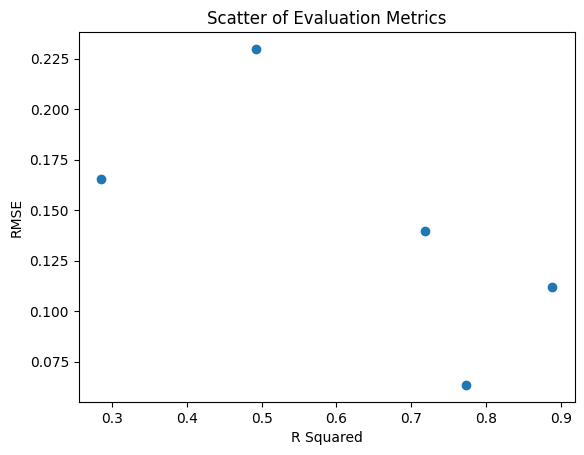

In [41]:
plt.figure()
plt.scatter(scores['R²'], scores['RMSE'])
plt.ylabel("RMSE")
plt.xlabel("R Squared")
plt.title("Scatter of Evaluation Metrics")
plt.show()

Spread on RMSE can now be seen to come from an outlier value. Also, perfromance scores on R² seem to form two tight groupings. This suggests that some of the train/test clusters may varry greatly in the target values they hold. Regardless, this bears investigating further.

Next on analysing coefficients:

ValueError: zero-size array to reduction operation fmin which has no identity

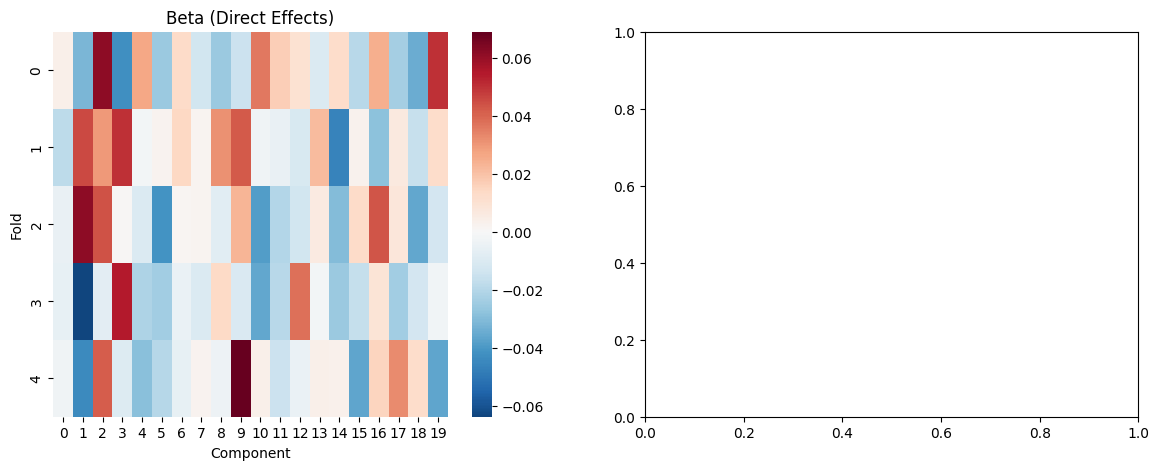

In [34]:
beta_matrix = np.vstack(scores['Beta'])    # shape: (n_folds, k)
theta_matrix = np.vstack(scores['Theta'])  # shape: (n_folds, k)

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Beta heatmap
sns.heatmap(beta_matrix, ax=axes[0], cmap='RdBu_r', center=0)
axes[0].set_title("Beta (Direct Effects)")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Fold")

# Theta heatmap
sns.heatmap(theta_matrix, ax=axes[1], cmap='RdBu_r', center=0)
axes[1].set_title("Theta (Spatial Effects)")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Fold")

plt.tight_layout()
plt.show()

These plots show that the model is currently unstable in CV since most PCs vary greatly in both coefficient sets. The most conistent components also seem to be of the smallest magnitude, meaning they are stable because the model consistently picks them out as being less relevant for prediction. 

It may bear worth highlighting though that component 1 and 2 consistently score high and consistent for direct coefficients with component 2 repeating this for spatial effects.

A scatterplot of coefficient means and spreads is produced next.

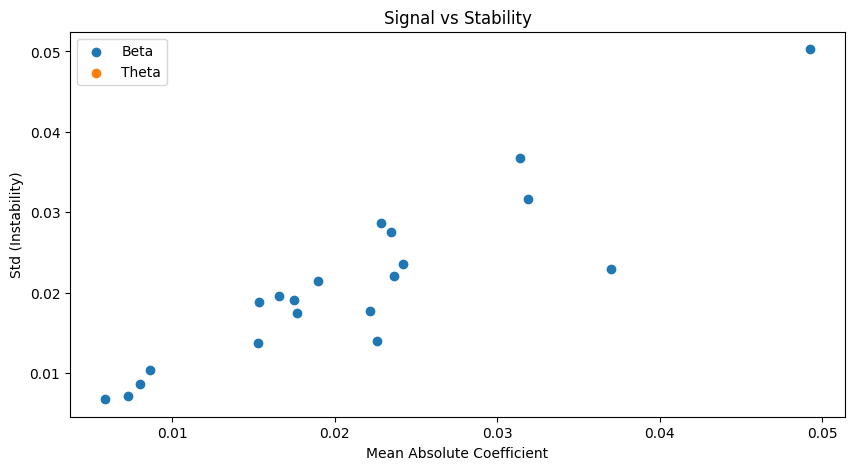

In [38]:
beta_std = np.std(beta_matrix, axis=0)
theta_std = np.std(theta_matrix, axis=0)

beta_mean = np.mean(np.abs(beta_matrix), axis=0)
theta_mean = np.mean(np.abs(theta_matrix), axis=0)

plt.figure(figsize=(10, 5))

plt.scatter(beta_mean, beta_std, label='Beta')
plt.scatter(theta_mean, theta_std, label='Theta')

plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Std (Instability)")
plt.title("Signal vs Stability")

plt.legend()
plt.show()

A near perfect correlation here suggests the model is instable. The more powerful a coefficient is for predicting, the more unstable it is across teh folds.

This could be due to deprivation not being equally distributed between clusters and so some folds may have test datasets which are significnatly higher or lower in deprivation than the training dataset.

To better confirm this, clusters are plotted with LSOA deprivation scores as a heatmap.

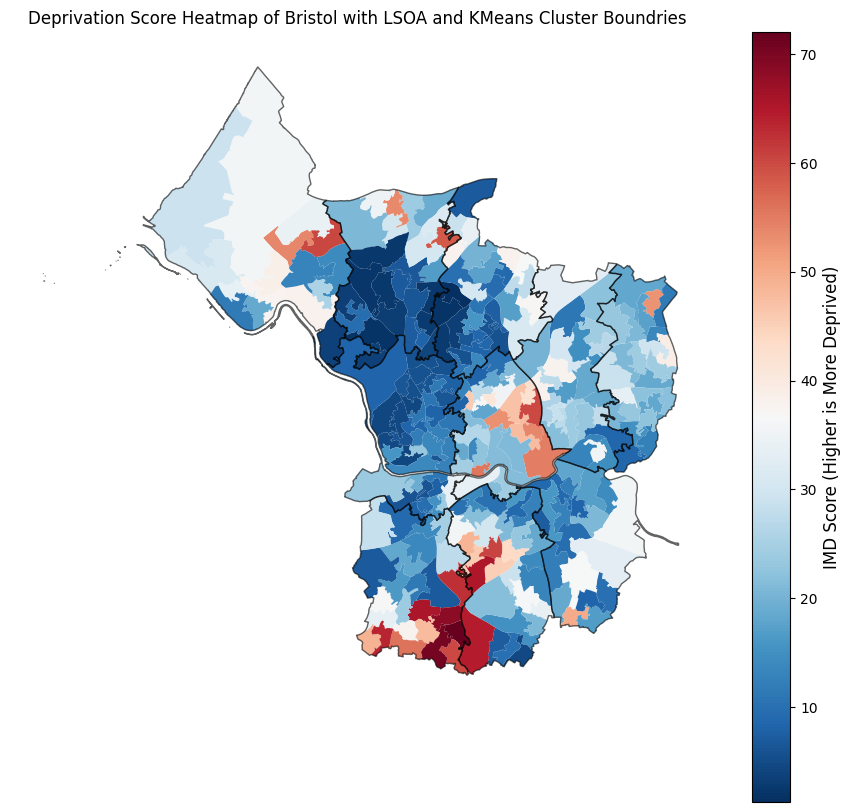

In [18]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot IMD score with color map and legend
gdf.plot(
    ax=ax,
    column='imd_score',
    cmap='RdBu_r',
    legend=True,
)


# Plot lsoa clusters
gdf.dissolve('cluster_id').boundary.plot(
    ax=ax,
    color='black',
    linewidth=1,
    alpha=0.6
)

# Format colourbar
cbar = ax.get_figure().axes[-1] 
cbar.set_ylabel("IMD Score (Higher is More Deprived)", fontsize=12)  # set the label of the legend

ax.set_xlim(-2.77, -2.5)
ax.set_axis_off()
ax.set_title("Deprivation Score Heatmap of Bristol with LSOA and KMeans Cluster Boundries")

plt.show()

This plot supports this suspicion since it can be seen that the cities lowest scoring and highest scoring LSOAs are grouped into two or three clusters. So, if the folds hold the cluster containing what looks like Heartcliffe and Knowle West for testing then the model’s performance metrics will likely come out weaker. Simmirlalry for the two clusters in North Bristol which seem to hold the least deprived LSOAs.

This however, is not damming for using the model since in use it will be trained on all LSOAs. It does however highlight the difficulties in using spatial cross validation. Also, it must be remembered that RMSE stayed consistently low and that the initial train/test split was good.

To better combat this, more data could be sourced and used. This notebook only makes use of the 2025 dataset, whereas deprivation scores also exist for 2019. Or alternatively, if the data pipeline is extended to fetch data from other UK cities with similar characteristics to Bristol, more data could be gained this way. Though it should be noted that the way the adjacency matrix is handled may need to be changed to accommodate for this.

Whilst these actions are slightly outside the scope of the notebook, regularisation is most certainly within it. L2 regularisation (Ridge) is used next to see if model performance can be improved.

### Regularisation

#### Ridge (L2)

In [35]:

ridge_eval_rows = []


fold = 0

print(type(y))


for train_idx, test_idx in gkf.split(X, y, groups=groups):
    # split
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]

    y_train, y_test = y[train_idx], y[test_idx]
    
    # scale
    scaler = StandardScaler().fit(X_train_raw)
    X_train_scaled = scaler.transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    # PCA fitted on train only
    pca = PCA(n_components=20).fit(X_train_scaled)
    X_train_pca = pca.transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    WX_train = w[np.ix_(train_idx, train_idx)] @ X_train_pca
    WX_test  = w[np.ix_(test_idx, train_idx)]  @ X_train_pca
    
    # combine
    X_train_slx = np.hstack([X_train_pca, WX_train])
    X_test_slx = np.hstack([X_test_pca, WX_test])
    
    # model
    for a in [0.1, 1, 10, 100, 1000]:
        model = Ridge(alpha=a).fit(X_train_slx, y_train)
        y_pred = model.predict(X_test_slx)


        ridge_eval_rows.append({
            'alpha': a,
            'fold': fold,
            'RMSE': mean_squared_error(y_test, y_pred),
            'R²': r2_score(y_test, y_pred)
        })
        
    fold += 1

ridge_eval_df = pd.DataFrame(ridge_eval_rows)

<class 'numpy.ndarray'>


The extensive set of plots below serve to display the effects of regularisation. All in all, they appear promising. Attention should be focused towards $a = 100$ which looks like the most ideal cost function value.

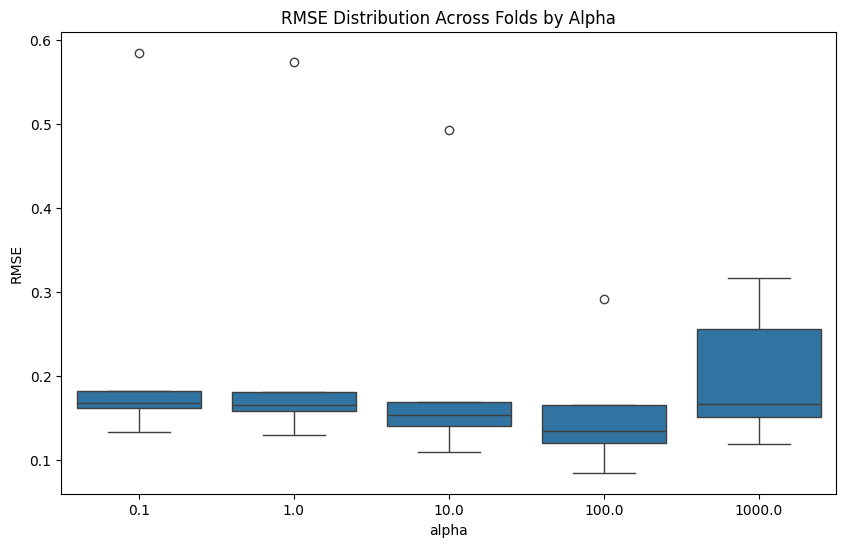

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(data=ridge_eval_df, x='alpha', y='RMSE')
plt.title('RMSE Distribution Across Folds by Alpha')
plt.show()

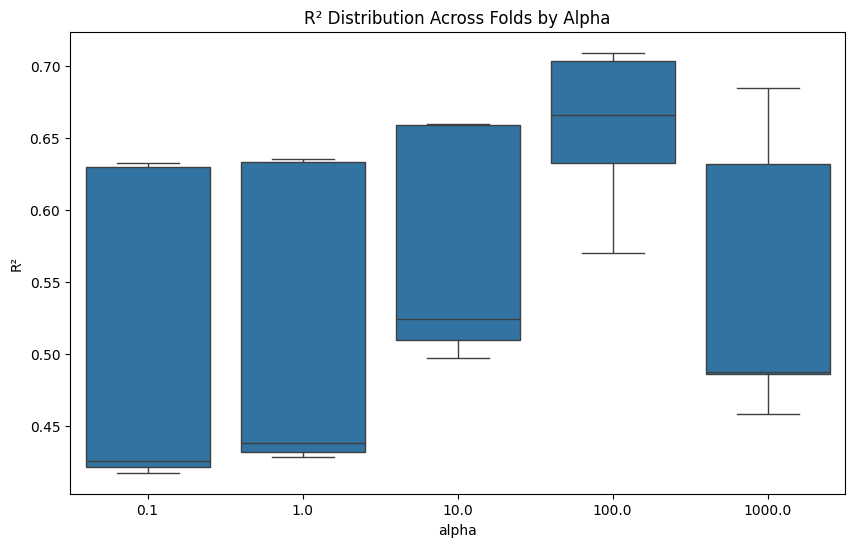

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(data=ridge_eval_df, x='alpha', y='R²')
plt.title('R² Distribution Across Folds by Alpha')
plt.show()

In [22]:
summary = ridge_eval_df.groupby('alpha').agg({
    'RMSE': ['mean', 'std'],
    'R²': ['mean', 'std']
}).reset_index()

summary.columns = ['alpha', 'rmse_mean', 'rmse_std', 'r2_mean', 'r2_std']

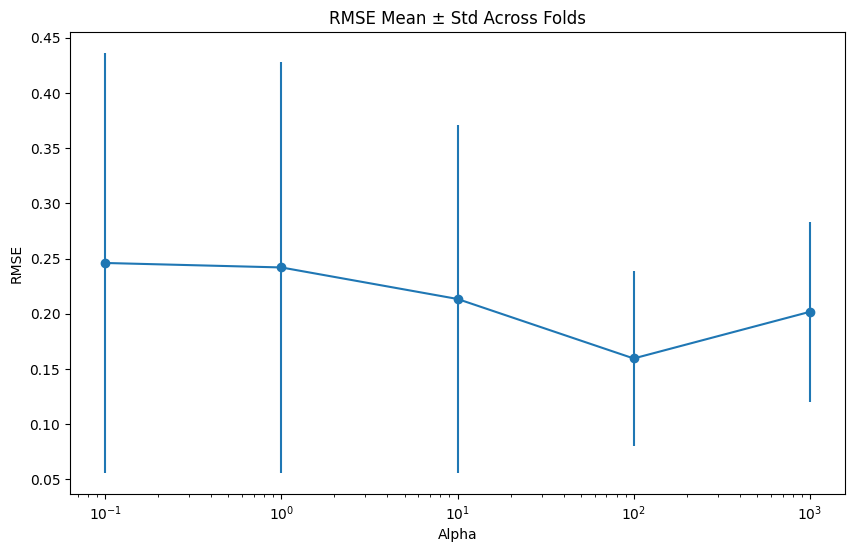

In [23]:
plt.figure(figsize=(10,6))
plt.errorbar(summary['alpha'], summary['rmse_mean'], yerr=summary['rmse_std'], marker='o')
plt.xscale('log')
plt.title('RMSE Mean ± Std Across Folds')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.show()

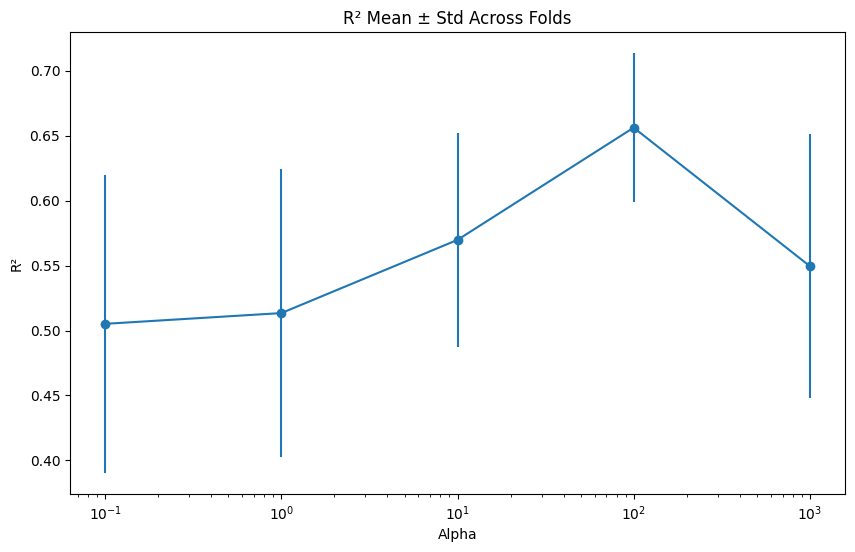

In [37]:
plt.figure(figsize=(10,6))
plt.errorbar(summary['alpha'], summary['r2_mean'], yerr=summary['r2_std'], marker='o')
plt.xscale('log')
plt.title('R² Mean ± Std Across Folds')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.show()

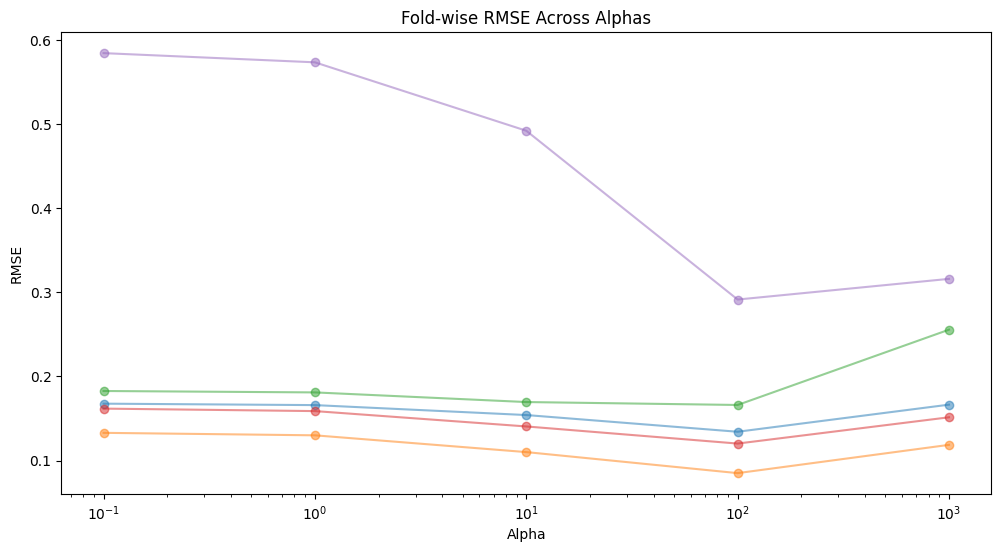

In [25]:
plt.figure(figsize=(12,6))

for fold in ridge_eval_df['fold'].unique():
    subset = ridge_eval_df[ridge_eval_df['fold'] == fold]
    plt.plot(subset['alpha'], subset['RMSE'], marker='o', alpha=0.5)

plt.xscale('log')
plt.title('Fold-wise RMSE Across Alphas')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.show()

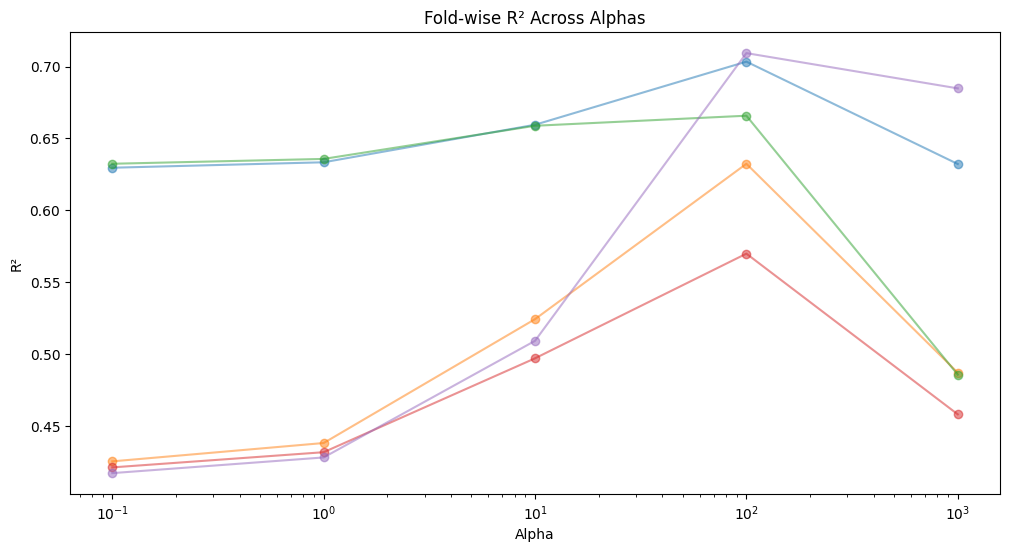

In [26]:
plt.figure(figsize=(12,6))

for fold in ridge_eval_df['fold'].unique():
    subset = ridge_eval_df[ridge_eval_df['fold'] == fold]
    plt.plot(subset['alpha'], subset['R²'], marker='o', alpha=0.5)

plt.xscale('log')
plt.title('Fold-wise R² Across Alphas')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.show()

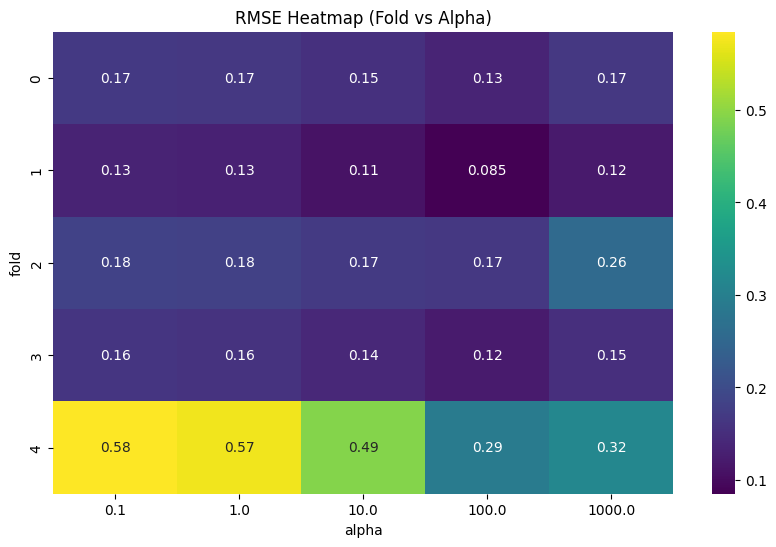

In [27]:
pivot = ridge_eval_df.pivot(index='fold', columns='alpha', values='RMSE')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='viridis')
plt.title('RMSE Heatmap (Fold vs Alpha)')
plt.show()

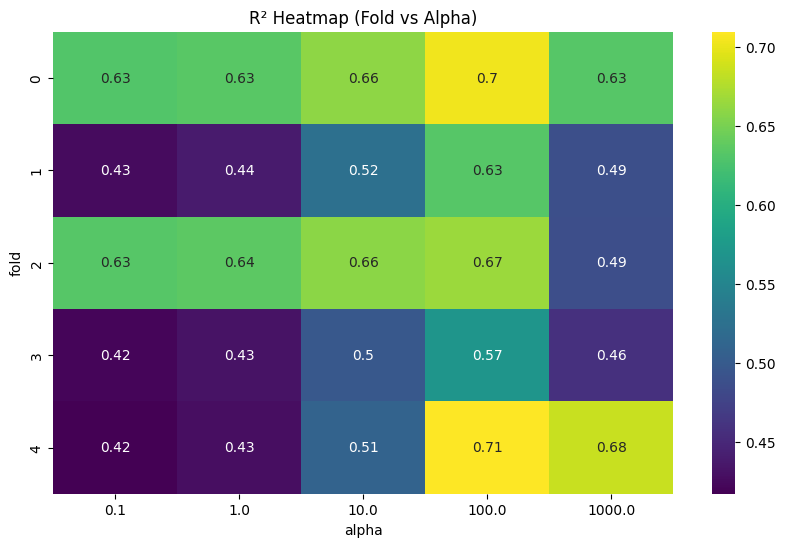

In [28]:
pivot = ridge_eval_df.pivot(index='fold', columns='alpha', values='R²')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='viridis')
plt.title('R² Heatmap (Fold vs Alpha)')
plt.show()

In summary, folds are brought closest in performance on $a = 100$. Spread is at its lowest here and it seems the effect of unstratified folds is somewhat eleviated. I believe these plots, together with the rest of the notebook, are sufficient to warrant including an SLX model with regularisation in further experiments.